In [2]:
# ============================================================
# YAPAY ZEKA DESTEKLİ LOJİSTİK ANAHAT OPTİMİZASYONU
# SANKA Takımı | TEKNOFEST 2026
# ============================================================

# Kurulum
!pip install lightgbm pulp -q

# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("✅ Tüm kütüphaneler yüklendi!")

✅ Tüm kütüphaneler yüklendi!


In [5]:
# ============================================================
# VERİ YÜKLEME
# ============================================================

df_desi  = pd.read_excel('/content/desi_talep 2.xlsx')
df_kira  = pd.read_excel('/content/kiralik_araclar.xlsx')
df_arac  = pd.read_excel('/content/arac_kapasite_maliyet.xlsx')
df_koord = pd.read_excel('/content/koordinatlar v2.xlsx')

# Tarih düzenle
df_desi['Tarih'] = pd.to_datetime(df_desi['Tarih'])

print("✅ Veriler yüklendi!")
print(f"  Desi Talep   : {df_desi.shape[0]} satır | "
      f"{df_desi['Tarih'].min().date()} → {df_desi['Tarih'].max().date()}")
print(f"  Kiralık Araç : {df_kira.shape[0]} satır")
print(f"  Araç Maliyet : {df_arac.shape[0]} satır")
print(f"  Koordinatlar : {df_koord.shape[0]} satır")
print(f"\n  OD Pair sayısı: {df_desi.groupby(['Çıkış Transfer Merkezi','Varış Transfer Merkezi']).ngroups}")
print(f"  Toplam gün    : {df_desi['Tarih'].nunique()}")

✅ Veriler yüklendi!
  Desi Talep   : 10770 satır | 2026-01-01 → 2026-05-10
  Kiralık Araç : 12 satır
  Araç Maliyet : 4 satır
  Koordinatlar : 18 satır

  OD Pair sayısı: 89
  Toplam gün    : 130


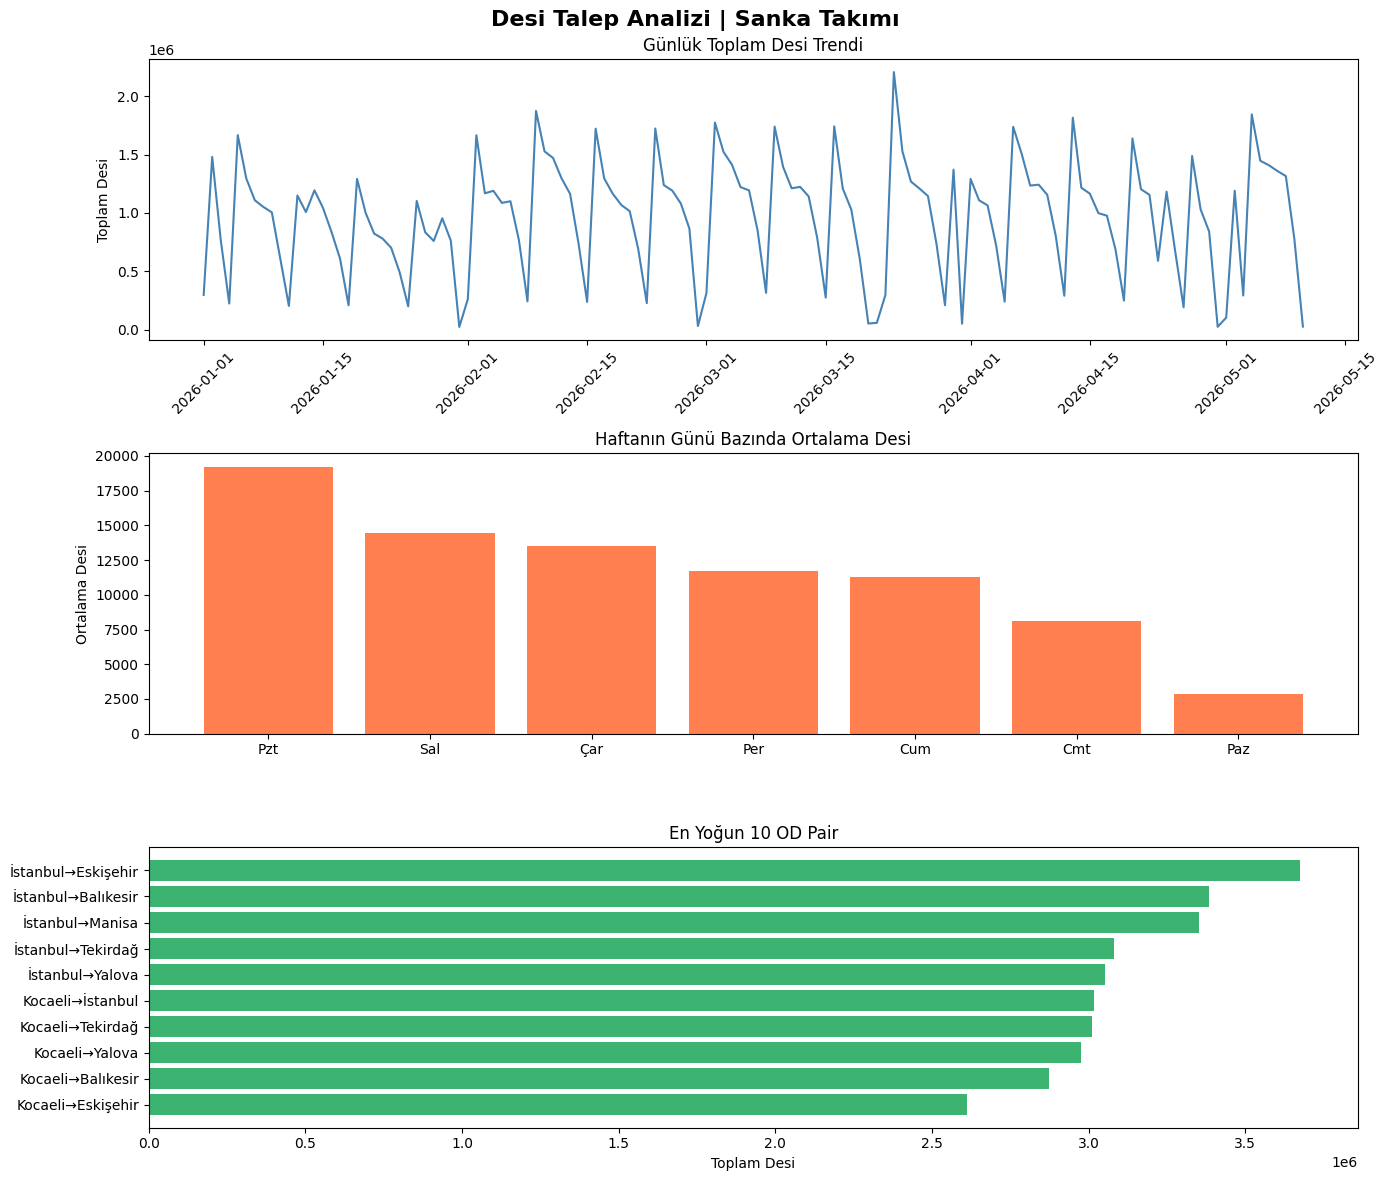

✅ EDA tamamlandı!
  Pazartesi ort:     19,223 desi (en yoğun)
  Pazar ort    :      2,892 desi (en sakin)
  Fark         : 6.6x


In [6]:
# ============================================================
# KEŞİFSEL VERİ ANALİZİ (EDA)
# ============================================================

df_desi['HaftaninGunu'] = df_desi['Tarih'].dt.dayofweek

# Günlük toplam desi
gunluk = df_desi.groupby('Tarih')['Toplam Desi'].sum()

# Haftanın günü ortalaması
gun_ort = df_desi.groupby('HaftaninGunu')['Toplam Desi'].mean()
gun_isimleri = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']

# En yoğun 10 OD pair
top10 = df_desi.groupby(
    ['Çıkış Transfer Merkezi','Varış Transfer Merkezi']
)['Toplam Desi'].sum().sort_values(ascending=False).head(10)
top10.index = [f"{c}→{v}" for c,v in top10.index]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Desi Talep Analizi | Sanka Takımı', fontsize=16, fontweight='bold')

axes[0].plot(gunluk.index, gunluk.values, color='steelblue', linewidth=1.5)
axes[0].set_title('Günlük Toplam Desi Trendi')
axes[0].set_ylabel('Toplam Desi')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(gun_isimleri, gun_ort.values, color='coral')
axes[1].set_title('Haftanın Günü Bazında Ortalama Desi')
axes[1].set_ylabel('Ortalama Desi')

axes[2].barh(top10.index[::-1], top10.values[::-1], color='mediumseagreen')
axes[2].set_title('En Yoğun 10 OD Pair')
axes[2].set_xlabel('Toplam Desi')

plt.tight_layout()
plt.savefig('eda_grafik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA tamamlandı!")
print(f"  Pazartesi ort: {gun_ort[0]:>10,.0f} desi (en yoğun)")
print(f"  Pazar ort    : {gun_ort[6]:>10,.0f} desi (en sakin)")
print(f"  Fark         : {gun_ort[0]/gun_ort[6]:.1f}x")

In [7]:
# ============================================================
# ANORMAL GÜN TESPİTİ (Bayramlar ve Eksik Veri)
# ============================================================

gunluk_toplam = df_desi.groupby('Tarih')['Toplam Desi'].sum().reset_index()
gunluk_toplam['HaftaninGunu'] = gunluk_toplam['Tarih'].dt.dayofweek

# Her haftanın günü için ortalama
gun_ort_dict = gunluk_toplam.groupby('HaftaninGunu')['Toplam Desi'].mean()

# Ortalamanın %30'undan düşük günler = anormal
gunluk_toplam['gun_ort']  = gunluk_toplam['HaftaninGunu'].map(gun_ort_dict)
gunluk_toplam['oran']     = gunluk_toplam['Toplam Desi'] / gunluk_toplam['gun_ort']

esik = 0.30
anormal_gunler = gunluk_toplam[
    gunluk_toplam['oran'] < esik
]['Tarih'].tolist()

print(f"Tespit edilen anormal günler ({len(anormal_gunler)} adet):")
gun_adlari = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']
for t in anormal_gunler:
    gun  = gun_adlari[t.dayofweek]
    desi = gunluk_toplam[gunluk_toplam['Tarih']==t]['Toplam Desi'].values[0]
    oran = gunluk_toplam[gunluk_toplam['Tarih']==t]['oran'].values[0]
    print(f"  {t.date()}  {gun:<4} → {desi:>10,.0f} desi  (ort. %{oran*100:.0f})")

# Temiz veri
df_temiz = df_desi[~df_desi['Tarih'].isin(anormal_gunler)].copy()
print(f"\nOrijinal veri : {len(df_desi):>6} satır")
print(f"Çıkarılan     : {len(df_desi)-len(df_temiz):>6} satır")
print(f"Temiz veri    : {len(df_temiz):>6} satır ✅")

Tespit edilen anormal günler (8 adet):
  2026-01-31  Cmt  →     22,067 desi  (ort. %3)
  2026-02-28  Cmt  →     29,904 desi  (ort. %5)
  2026-03-20  Cum  →     51,526 desi  (ort. %5)
  2026-03-21  Cmt  →     57,758 desi  (ort. %9)
  2026-03-31  Sal  →     50,026 desi  (ort. %4)
  2026-04-30  Per  →     23,395 desi  (ort. %2)
  2026-05-01  Cum  →    102,173 desi  (ort. %11)
  2026-05-10  Paz  →     25,203 desi  (ort. %11)

Orijinal veri :  10770 satır
Çıkarılan     :    353 satır
Temiz veri    :  10417 satır ✅


In [8]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df_fe = df_temiz.sort_values(
    ['Çıkış Transfer Merkezi', 'Varış Transfer Merkezi', 'Tarih']
).copy()

# Zaman özellikleri
df_fe['HaftaninGunu']  = df_fe['Tarih'].dt.dayofweek
df_fe['HaftaNo']       = df_fe['Tarih'].dt.isocalendar().week.astype(int)
df_fe['Ay']            = df_fe['Tarih'].dt.month
df_fe['YilinGunu']     = df_fe['Tarih'].dt.dayofyear
df_fe['AyinGunu']      = df_fe['Tarih'].dt.day

def add_lag_features(group):
    group = group.sort_values('Tarih').copy()
    # Lag: geçmiş değerler
    group['lag_7']  = group['Toplam Desi'].shift(7)
    group['lag_14'] = group['Toplam Desi'].shift(14)
    group['lag_21'] = group['Toplam Desi'].shift(21)
    # Rolling: kayan ortalama
    group['rolling_mean_7']  = group['Toplam Desi'].shift(1).rolling(7).mean()
    group['rolling_mean_14'] = group['Toplam Desi'].shift(1).rolling(14).mean()
    group['rolling_std_7']   = group['Toplam Desi'].shift(1).rolling(7).std()
    return group

df_fe = df_fe.groupby(
    ['Çıkış Transfer Merkezi', 'Varış Transfer Merkezi'],
    group_keys=False
).apply(add_lag_features).reset_index(drop=True)

df_fe = df_fe.dropna().reset_index(drop=True)

feature_cols = [
    'HaftaninGunu', 'HaftaNo', 'Ay', 'YilinGunu', 'AyinGunu',
    'lag_7', 'lag_14', 'lag_21',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7'
]
target_col = 'Toplam Desi'

print(f"✅ Feature engineering tamamlandı!")
print(f"  Toplam satır : {len(df_fe)}")
print(f"  Feature sayısı: {len(feature_cols)}")
print(f"  Featurelar   : {feature_cols}")

✅ Feature engineering tamamlandı!
  Toplam satır : 8548
  Feature sayısı: 11
  Featurelar   : ['HaftaninGunu', 'HaftaNo', 'Ay', 'YilinGunu', 'AyinGunu', 'lag_7', 'lag_14', 'lag_21', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']


In [9]:
# ============================================================
# TRAIN / VALİDATİON / TEST BÖLÜMÜ + NAİVE BASELİNE
# ============================================================

# Zamansal bölüm (shuffle yok!)
train_bitis      = '2026-04-26'
validation_bitis = '2026-05-03'

X_train = df_fe[df_fe['Tarih'] <= train_bitis][feature_cols]
y_train = df_fe[df_fe['Tarih'] <= train_bitis][target_col]
X_val   = df_fe[(df_fe['Tarih'] > train_bitis) &
                (df_fe['Tarih'] <= validation_bitis)][feature_cols]
y_val   = df_fe[(df_fe['Tarih'] > train_bitis) &
                (df_fe['Tarih'] <= validation_bitis)][target_col]
X_test  = df_fe[df_fe['Tarih'] > validation_bitis][feature_cols]
y_test  = df_fe[df_fe['Tarih'] > validation_bitis][target_col]

print(f"📊 Veri Bölümü:")
print(f"  Train      : {len(X_train):>6} satır | "
      f"{df_fe[df_fe['Tarih'] <= train_bitis]['Tarih'].min().date()} → "
      f"{df_fe[df_fe['Tarih'] <= train_bitis]['Tarih'].max().date()}")
print(f"  Validation : {len(X_val):>6} satır | "
      f"{df_fe[(df_fe['Tarih'] > train_bitis) & (df_fe['Tarih'] <= validation_bitis)]['Tarih'].min().date()} → "
      f"{df_fe[(df_fe['Tarih'] > train_bitis) & (df_fe['Tarih'] <= validation_bitis)]['Tarih'].max().date()}")
print(f"  Test       : {len(X_test):>6} satır | "
      f"{df_fe[df_fe['Tarih'] > validation_bitis]['Tarih'].min().date()} → "
      f"{df_fe[df_fe['Tarih'] > validation_bitis]['Tarih'].max().date()}")

# Naive Baseline — 7 gün önceki değeri kullan
def metrik_hesapla(gercek, tahmin, isim):
    mae  = mean_absolute_error(gercek, tahmin)
    rmse = np.sqrt(mean_squared_error(gercek, tahmin))
    mask = gercek > 10
    mape = np.mean(np.abs((gercek[mask] - tahmin[mask]) / gercek[mask])) * 100
    print(f"  {isim}: MAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE=%{mape:.1f}")
    return mae, rmse

df_sorted = df_temiz.sort_values(
    ['Çıkış Transfer Merkezi', 'Varış Transfer Merkezi', 'Tarih']
).copy()
df_sorted['naive'] = df_sorted.groupby(
    ['Çıkış Transfer Merkezi', 'Varış Transfer Merkezi']
)['Toplam Desi'].shift(7)

val_naive  = df_sorted[
    (df_sorted['Tarih'] > train_bitis) &
    (df_sorted['Tarih'] <= validation_bitis)
].dropna()
test_naive = df_sorted[df_sorted['Tarih'] > validation_bitis].dropna()

print(f"\n📊 Naive Baseline:")
val_mae_naive, _  = metrik_hesapla(
    val_naive['Toplam Desi'].values,
    val_naive['naive'].values, "Validation"
)
test_mae_naive, _ = metrik_hesapla(
    test_naive['Toplam Desi'].values,
    test_naive['naive'].values, "Test      "
)
print(f"\n⚠️  XGBoost ve LightGBM bu değerleri geçmek zorunda!")

📊 Veri Bölümü:
  Train      :   7585 satır | 2026-01-22 → 2026-04-26
  Validation :    438 satır | 2026-04-27 → 2026-05-03
  Test       :    525 satır | 2026-05-04 → 2026-05-09

📊 Naive Baseline:
  Validation: MAE=5,073 | RMSE=7,729 | MAPE=%458.8
  Test      : MAE=7,511 | RMSE=10,831 | MAPE=%63.2

⚠️  XGBoost ve LightGBM bu değerleri geçmek zorunda!


🔄 XGBoost eğitiliyor...
🔄 LightGBM eğitiliyor...
  XGBoost  Val: MAE=3,256 | RMSE=4,829 | MAPE=%207.4
  XGBoost Test: MAE=2,841 | RMSE=4,256 | MAPE=%37.7
  LightGBM Val: MAE=3,166 | RMSE=4,733 | MAPE=%196.3
  LightGBM Test: MAE=2,498 | RMSE=3,709 | MAPE=%36.6

KARŞILAŞTIRMA TABLOSU
Model                   Val MAE   Test MAE
---------------------------------------------
Naive Baseline            5,073      7,511
XGBoost                   3,256      2,841
LightGBM                  3,166      2,498

🏆 KAZANAN: LightGBM


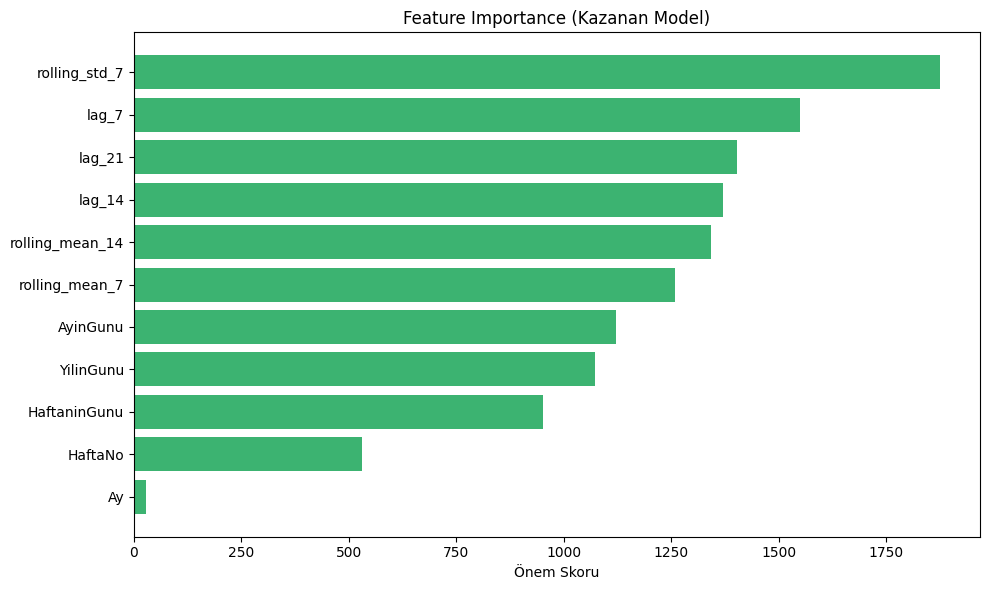

✅ Model karşılaştırması tamamlandı!


In [10]:
# ============================================================
# XGBOOST ve LightGBM MODELLERİ
# ============================================================

# XGBoost
print("🔄 XGBoost eğitiliyor...")
xgb_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_val_pred  = np.maximum(xgb_model.predict(X_val), 0)
xgb_test_pred = np.maximum(xgb_model.predict(X_test), 0)

# LightGBM
print("🔄 LightGBM eğitiliyor...")
lgbm_model = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_val_pred  = np.maximum(lgbm_model.predict(X_val), 0)
lgbm_test_pred = np.maximum(lgbm_model.predict(X_test), 0)

# Metrikler
xgb_val_mae,  _ = metrik_hesapla(y_val.values,  xgb_val_pred,  "XGBoost  Val")
xgb_test_mae, _ = metrik_hesapla(y_test.values, xgb_test_pred, "XGBoost Test")
lgbm_val_mae,  _ = metrik_hesapla(y_val.values,  lgbm_val_pred,  "LightGBM Val")
lgbm_test_mae, _ = metrik_hesapla(y_test.values, lgbm_test_pred, "LightGBM Test")

# Karşılaştırma tablosu
print(f"\n{'='*55}")
print(f"KARŞILAŞTIRMA TABLOSU")
print(f"{'='*55}")
print(f"{'Model':<20} {'Val MAE':>10} {'Test MAE':>10}")
print(f"{'-'*45}")
print(f"{'Naive Baseline':<20} {val_mae_naive:>10,.0f} {test_mae_naive:>10,.0f}")
print(f"{'XGBoost':<20} {xgb_val_mae:>10,.0f} {xgb_test_mae:>10,.0f}")
print(f"{'LightGBM':<20} {lgbm_val_mae:>10,.0f} {lgbm_test_mae:>10,.0f}")

# Kazanan
if lgbm_val_mae < xgb_val_mae:
    print(f"\n🏆 KAZANAN: LightGBM")
    best_model = lgbm_model
else:
    print(f"\n🏆 KAZANAN: XGBoost")
    best_model = xgb_model

# Feature importance
fi = pd.Series(best_model.feature_importances_, index=feature_cols)
fi = fi.sort_values(ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(fi.index, fi.values, color='mediumseagreen')
plt.title('Feature Importance (Kazanan Model)')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Model karşılaştırması tamamlandı!")

Walk Forward Validation başlıyor... (10 pencere)

  Pencere  1 | Test: 2026-03-02 → 2026-03-08 | MAE:    2,145 | RMSE:    3,302
  Pencere  2 | Test: 2026-03-09 → 2026-03-15 | MAE:    1,613 | RMSE:    2,380
  Pencere  3 | Test: 2026-03-16 → 2026-03-22 | MAE:    3,892 | RMSE:    5,840
  Pencere  4 | Test: 2026-03-23 → 2026-03-29 | MAE:    6,654 | RMSE:    9,720
  Pencere  5 | Test: 2026-03-30 → 2026-04-05 | MAE:    2,599 | RMSE:    4,113
  Pencere  6 | Test: 2026-04-06 → 2026-04-12 | MAE:    1,953 | RMSE:    2,806
  Pencere  7 | Test: 2026-04-13 → 2026-04-19 | MAE:    1,711 | RMSE:    2,525
  Pencere  8 | Test: 2026-04-20 → 2026-04-26 | MAE:    2,279 | RMSE:    3,602
  Pencere  9 | Test: 2026-04-27 → 2026-05-03 | MAE:    3,166 | RMSE:    4,733
  Pencere 10 | Test: 2026-05-04 → 2026-05-10 | MAE:    2,612 | RMSE:    3,807

WALK FORWARD ÖZET
  Ortalama MAE :      2,862 desi
  Ortalama RMSE:      4,283 desi
  En iyi MAE   :      1,613 (Pencere 2)
  En kötü MAE  :      6,654 (Pencere 4)
  Nai

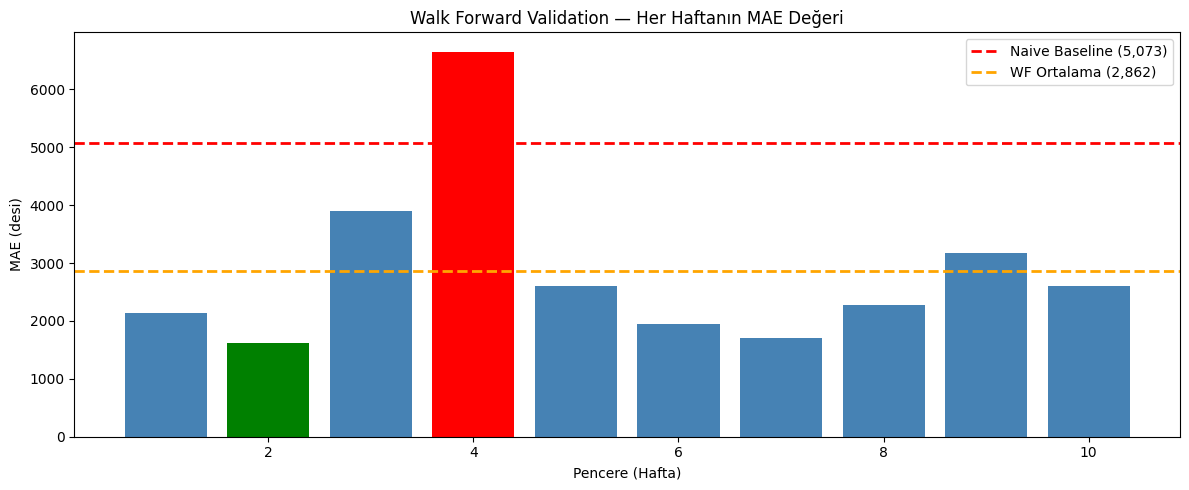

✅ Walk Forward tamamlandı!


In [11]:
# ============================================================
# WALK FORWARD VALIDATION
# ============================================================

MIN_TRAIN_HAFTA = 8
pazartesiler = sorted(df_temiz[
    df_temiz['Tarih'].dt.dayofweek == 0
]['Tarih'].dt.date.unique())

wf_sonuclar = []
print(f"Walk Forward Validation başlıyor... ({len(pazartesiler)-MIN_TRAIN_HAFTA} pencere)\n")

for i in range(MIN_TRAIN_HAFTA, len(pazartesiler)):
    train_bitis_wf = pd.Timestamp(pazartesiler[i]) - pd.Timedelta(days=1)
    test_baslangic = pd.Timestamp(pazartesiler[i])
    test_bitis     = test_baslangic + pd.Timedelta(days=6)

    train_wf = df_fe[df_fe['Tarih'] <= train_bitis_wf]
    test_wf  = df_fe[(df_fe['Tarih'] >= test_baslangic) &
                     (df_fe['Tarih'] <= test_bitis)]

    if len(test_wf) == 0:
        continue

    model_wf = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
    )
    model_wf.fit(train_wf[feature_cols], train_wf[target_col])
    pred_wf = np.maximum(model_wf.predict(test_wf[feature_cols]), 0)
    mae  = mean_absolute_error(test_wf[target_col].values, pred_wf)
    rmse = np.sqrt(mean_squared_error(test_wf[target_col].values, pred_wf))

    wf_sonuclar.append({
        'Pencere'     : i - MIN_TRAIN_HAFTA + 1,
        'Test Haftası': f"{test_baslangic.date()} → {test_bitis.date()}",
        'MAE'         : round(mae, 0),
        'RMSE'        : round(rmse, 0),
    })
    print(f"  Pencere {i-MIN_TRAIN_HAFTA+1:>2} | "
          f"Test: {test_baslangic.date()} → {test_bitis.date()} | "
          f"MAE: {mae:>8,.0f} | RMSE: {rmse:>8,.0f}")

df_wf = pd.DataFrame(wf_sonuclar)
print(f"\n{'='*50}")
print(f"WALK FORWARD ÖZET")
print(f"{'='*50}")
print(f"  Ortalama MAE : {df_wf['MAE'].mean():>10,.0f} desi")
print(f"  Ortalama RMSE: {df_wf['RMSE'].mean():>10,.0f} desi")
print(f"  En iyi MAE   : {df_wf['MAE'].min():>10,.0f} (Pencere {df_wf.loc[df_wf['MAE'].idxmin(),'Pencere']})")
print(f"  En kötü MAE  : {df_wf['MAE'].max():>10,.0f} (Pencere {df_wf.loc[df_wf['MAE'].idxmax(),'Pencere']})")
print(f"  Naive vs WF  : {val_mae_naive:,.0f} → {df_wf['MAE'].mean():,.0f} "
      f"(%{(1-df_wf['MAE'].mean()/val_mae_naive)*100:.0f} iyileşme) ✅")

# Grafik
plt.figure(figsize=(12, 5))
renkler = ['red' if m == df_wf['MAE'].max()
           else 'green' if m == df_wf['MAE'].min()
           else 'steelblue' for m in df_wf['MAE']]
plt.bar(df_wf['Pencere'], df_wf['MAE'], color=renkler)
plt.axhline(y=val_mae_naive, color='red', linestyle='--',
            linewidth=2, label=f'Naive Baseline ({val_mae_naive:,.0f})')
plt.axhline(y=df_wf['MAE'].mean(), color='orange', linestyle='--',
            linewidth=2, label=f'WF Ortalama ({df_wf["MAE"].mean():,.0f})')
plt.title('Walk Forward Validation — Her Haftanın MAE Değeri')
plt.xlabel('Pencere (Hafta)')
plt.ylabel('MAE (desi)')
plt.legend()
plt.tight_layout()
plt.savefig('walk_forward.png', dpi=150)
plt.show()
print("✅ Walk Forward tamamlandı!")

In [12]:
# ============================================================
# FİNAL MODEL + 11-17 MAYIS TAHMİNİ
# ============================================================

# Tüm veriyle final model eğit
print("🔄 Final model tüm veriyle eğitiliyor...")
final_model = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
final_model.fit(df_fe[feature_cols], df_fe[target_col])
print("✅ Final model hazır!")

# 11-17 Mayıs için tahmin üret
target_dates = pd.date_range('2026-05-11', '2026-05-17', freq='D')
od_pairs     = df_desi[['Çıkış Transfer Merkezi',
                         'Varış Transfer Merkezi']].drop_duplicates()
tahmin_listesi = []

for _, od in od_pairs.iterrows():
    cikis = od['Çıkış Transfer Merkezi']
    varis = od['Varış Transfer Merkezi']
    od_gecmis = df_temiz[
        (df_temiz['Çıkış Transfer Merkezi'] == cikis) &
        (df_temiz['Varış Transfer Merkezi'] == varis)
    ].sort_values('Tarih').set_index('Tarih')['Toplam Desi']

    for tarih in target_dates:
        def get_lag(n):
            lag_tarih = tarih - pd.Timedelta(days=n)
            return od_gecmis[lag_tarih] if lag_tarih in od_gecmis.index else od_gecmis.mean()

        son_7  = od_gecmis[(od_gecmis.index >= tarih-pd.Timedelta(days=8)) &
                            (od_gecmis.index < tarih)]
        son_14 = od_gecmis[(od_gecmis.index >= tarih-pd.Timedelta(days=15)) &
                            (od_gecmis.index < tarih)]

        tahmin_listesi.append({
            'Çıkış Transfer Merkezi': cikis,
            'Varış Transfer Merkezi': varis,
            'Tarih'                 : tarih.date(),
            'HaftaninGunu'          : tarih.dayofweek,
            'HaftaNo'               : tarih.isocalendar()[1],
            'Ay'                    : tarih.month,
            'YilinGunu'             : tarih.dayofyear,
            'AyinGunu'              : tarih.day,
            'lag_7'                 : get_lag(7),
            'lag_14'                : get_lag(14),
            'lag_21'                : get_lag(21),
            'rolling_mean_7'        : son_7.mean()  if len(son_7)  > 0 else od_gecmis.mean(),
            'rolling_mean_14'       : son_14.mean() if len(son_14) > 0 else od_gecmis.mean(),
            'rolling_std_7'         : son_7.std()   if len(son_7)  > 1 else 0,
        })

df_tahmin = pd.DataFrame(tahmin_listesi)
df_tahmin['Tahmin Edilen Desi'] = np.maximum(
    final_model.predict(df_tahmin[feature_cols]), 0
)

# Sağlık kontrolü
od_gun_ort = df_temiz.groupby([
    'Çıkış Transfer Merkezi', 'Varış Transfer Merkezi',
    df_temiz['Tarih'].dt.dayofweek
])['Toplam Desi'].mean().reset_index()
od_gun_ort.columns = ['Çıkış Transfer Merkezi', 'Varış Transfer Merkezi',
                       'HaftaninGunu', 'Gecmis Ortalama']

df_tahmin = df_tahmin.merge(od_gun_ort,
    on=['Çıkış Transfer Merkezi','Varış Transfer Merkezi','HaftaninGunu'],
    how='left')

def saglik_kontrolu(row):
    tahmin = row['Tahmin Edilen Desi']
    gecmis = row['Gecmis Ortalama']
    if pd.isna(gecmis) or gecmis == 0:
        return tahmin
    if tahmin < gecmis * 0.20 or tahmin > gecmis * 3.00:
        return gecmis
    return tahmin

df_tahmin['Tahmin Edilen Desi'] = df_tahmin.apply(saglik_kontrolu, axis=1)

# Günlük özet
print("\n📦 11-17 Mayıs Tahmin Özeti:")
gunluk = df_tahmin.groupby('Tarih')['Tahmin Edilen Desi'].sum()
gun_adlari = ['Pazartesi','Salı','Çarşamba','Perşembe','Cuma','Cumartesi','Pazar']
for tarih, desi in gunluk.items():
    gun = gun_adlari[pd.Timestamp(tarih).dayofweek]
    print(f"  {tarih}  {gun:<12} →  {desi:>12,.0f} desi")
print(f"\n  📊 Haftalık TOPLAM: {gunluk.sum():>12,.0f} desi")
print(f"  Satır sayısı    : {len(df_tahmin)}")

🔄 Final model tüm veriyle eğitiliyor...
✅ Final model hazır!

📦 11-17 Mayıs Tahmin Özeti:
  2026-05-11  Pazartesi    →     1,775,518 desi
  2026-05-12  Salı         →     1,463,601 desi
  2026-05-13  Çarşamba     →     1,301,279 desi
  2026-05-14  Perşembe     →     1,148,468 desi
  2026-05-15  Cuma         →     1,151,624 desi
  2026-05-16  Cumartesi    →       926,827 desi
  2026-05-17  Pazar        →       324,459 desi

  📊 Haftalık TOPLAM:    8,091,776 desi
  Satır sayısı    : 623


In [13]:
# ============================================================
# OPTİMİZASYON — SPOT ARAÇ PLANLAMASI
# ============================================================

# Haversine mesafe fonksiyonu
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

koord_dict = df_koord.set_index('Transfer Merkezi')[['Enlem','Boylam']].to_dict('index')

def mesafe_hesapla(cikis, varis):
    if cikis not in koord_dict or varis not in koord_dict:
        return 500
    c1 = koord_dict[cikis]; c2 = koord_dict[varis]
    return haversine(c1['Enlem'], c1['Boylam'], c2['Enlem'], c2['Boylam'])

# Araç bilgileri
arac_dict = {}
for _, r in df_arac.iterrows():
    arac_dict[r['Araç Adı']] = {
        'kapasite'      : r['Kapasite (desi)'],
        'kiralik_sabit' : r['Kiralık Araç Günlük Kira (TL)'],
        'kiralik_km'    : r['Kiralık Araç Kilometre Başına Maliyet (TL)'],
        'spot_sabit'    : r['Spot Araç Sabit Günlük Maliyet (TL)'],
        'spot_km'       : r['Spot Kilometre Başına Maliyet (TL)'],
    }

# Kiralık araç bilgileri
kiralik_bilgi = {}
for _, r in df_kira.iterrows():
    cikis = r['Çıkış Transfer Merkezi']; varis = r['Varış Transfer Merkezi']
    arac_t = r['Araç Türü']; adet = r['Araç sayısı']
    km = mesafe_hesapla(cikis, varis)
    bilgi = arac_dict[arac_t]
    key = (cikis, varis)
    if key not in kiralik_bilgi:
        kiralik_bilgi[key] = {'kapasite': 0, 'maliyet': 0, 'detay': []}
    kiralik_bilgi[key]['kapasite'] += adet * bilgi['kapasite']
    kiralik_bilgi[key]['maliyet']  += adet * (bilgi['kiralik_sabit'] + bilgi['kiralik_km'] * km)
    kiralik_bilgi[key]['detay'].append(f"{adet}x{arac_t}")

# Spot araç seçim fonksiyonu
spot_arac_tipleri = ['Tır', 'Kamyon', 'Hafif Kamyon', 'Kamyonet']

def spot_arac_sec(talep_desi, km):
    if talep_desi <= 0:
        return [], 0
    en_iyi_maliyet = float('inf')
    en_iyi_tip = None; en_iyi_adet = 0
    for tip in spot_arac_tipleri:
        bilgi = arac_dict[tip]
        if talep_desi < bilgi['kapasite'] * 0.10:
            continue
        adet    = int(np.ceil(talep_desi / bilgi['kapasite']))
        maliyet = adet * (bilgi['spot_sabit'] + bilgi['spot_km'] * km)
        if maliyet < en_iyi_maliyet:
            en_iyi_maliyet = maliyet
            en_iyi_tip = tip
            en_iyi_adet = adet
    if en_iyi_tip is None:
        return [], 0
    return [{'tip': en_iyi_tip, 'adet': en_iyi_adet,
             'maliyet': en_iyi_maliyet}], en_iyi_maliyet

# Ana optimizasyon döngüsü
sonuc_listesi = []
toplam_spot_maliyet = 0
toplam_kiralik_maliyet = 0

for tarih in sorted(pd.to_datetime(df_tahmin['Tarih']).unique()):
    gun_tahmin = df_tahmin[
        pd.to_datetime(df_tahmin['Tarih']) == tarih
    ]

    for (cikis, varis), kbilgi in kiralik_bilgi.items():
        toplam_kiralik_maliyet += kbilgi['maliyet']

    for _, row in gun_tahmin.iterrows():
        cikis = row['Çıkış Transfer Merkezi']
        varis = row['Varış Transfer Merkezi']
        talep = row['Tahmin Edilen Desi']
        km    = mesafe_hesapla(cikis, varis)
        key   = (cikis, varis)

        kiralik_kap     = kiralik_bilgi.get(key, {}).get('kapasite', 0)
        kiralik_maliyet = kiralik_bilgi.get(key, {}).get('maliyet', 0)
        kiralik_detay   = ', '.join(kiralik_bilgi.get(key, {}).get('detay', []))
        kiralik_karsilanan = min(talep, kiralik_kap)
        spot_talep = max(0, talep - kiralik_kap)
        spot_araclar, spot_maliyet = spot_arac_sec(spot_talep, km)
        toplam_spot_maliyet += spot_maliyet

        if kiralik_kap > 0:
            sonuc_listesi.append({
                'Tarih'       : str(tarih.date()),
                'Araç Tipi'   : f'Kiralık {kiralik_detay}',
                'Çıkış TM'    : cikis,
                'Varış TM'    : varis,
                'Atanan Desi' : round(kiralik_karsilanan, 2),
                'Maliyet (TL)': round(kiralik_maliyet, 2),
                'Mesafe (km)' : round(km, 1),
                'Doluluk %'   : round(kiralik_karsilanan/kiralik_kap*100, 1)
            })

        for sa in spot_araclar:
            if sa['adet'] > 0 and spot_talep > 0:
                kapasite = arac_dict[sa['tip']]['kapasite'] * sa['adet']
                sonuc_listesi.append({
                    'Tarih'       : str(tarih.date()),
                    'Araç Tipi'   : f"Spot {sa['tip']}",
                    'Çıkış TM'    : cikis,
                    'Varış TM'    : varis,
                    'Atanan Desi' : round(spot_talep, 2),
                    'Maliyet (TL)': round(sa['maliyet'], 2),
                    'Mesafe (km)' : round(km, 1),
                    'Doluluk %'   : round(spot_talep/kapasite*100, 1)
                })

df_sonuc = pd.DataFrame(sonuc_listesi)

# %10 altı spot araçları temizle
df_plan = df_sonuc[
    ~((df_sonuc['Araç Tipi'].str.startswith('Spot')) &
      (df_sonuc['Doluluk %'] < 10))
].copy()

spot_maliyet_final   = df_plan[df_plan['Araç Tipi'].str.startswith('Spot')]['Maliyet (TL)'].sum()
toplam_maliyet_final = toplam_kiralik_maliyet + spot_maliyet_final

print("✅ Optimizasyon tamamlandı!")
print(f"  Toplam satır    : {len(df_plan)}")
print(f"  Kiralık maliyet : {toplam_kiralik_maliyet:>15,.0f} TL")
print(f"  Spot maliyet    : {spot_maliyet_final:>15,.0f} TL")
print(f"  {'─'*40}")
print(f"  TOPLAM MALİYET  : {toplam_maliyet_final:>15,.0f} TL")
print(f"\n  Min doluluk     : %{df_plan[df_plan['Araç Tipi'].str.startswith('Spot')]['Doluluk %'].min():.1f}")
print(f"  %10 altı satır  : {len(df_plan[(df_plan['Araç Tipi'].str.startswith('Spot')) & (df_plan['Doluluk %'] < 10)])}")

✅ Optimizasyon tamamlandı!
  Toplam satır    : 667
  Kiralık maliyet :         802,744 TL
  Spot maliyet    :      10,543,956 TL
  ────────────────────────────────────────
  TOPLAM MALİYET  :      11,346,700 TL

  Min doluluk     : %10.7
  %10 altı satır  : 0


In [14]:
# ============================================================
# EXCEL ÇIKTILARI KAYDET
# ============================================================

# 1. Tahmin Excel
df_tahmin_cikti = df_tahmin[[
    'Tarih', 'Çıkış Transfer Merkezi',
    'Varış Transfer Merkezi', 'Tahmin Edilen Desi'
]].copy()
df_tahmin_cikti['Tahmin Edilen Desi'] = df_tahmin_cikti['Tahmin Edilen Desi'].round(2)
df_tahmin_cikti.to_excel('tahmin_11_17_mayis.xlsx', index=False)

# 2. Araç Planlama Excel
df_plan.to_excel('arac_planlama_11_17_mayis.xlsx', index=False)

print("✅ Excel dosyaları kaydedildi!")
print(f"\n  tahmin_11_17_mayis.xlsx")
print(f"    Satır sayısı : {len(df_tahmin_cikti)}")
print(f"    Toplam desi  : {df_tahmin_cikti['Tahmin Edilen Desi'].sum():,.0f}")

print(f"\n  arac_planlama_11_17_mayis.xlsx")
print(f"    Satır sayısı : {len(df_plan)}")
print(f"    Toplam maliyet: {df_plan['Maliyet (TL)'].sum():,.0f} TL")

print(f"\n{'='*50}")
print(f"📊 FİNAL ÖZET — Sanka Takımı")
print(f"{'='*50}")
print(f"  Tahmin yöntemi : LightGBM + Walk Forward")
print(f"  Walk Forward MAE: {df_wf['MAE'].mean():,.0f} desi (Naive: {val_mae_naive:,.0f})")
print(f"  Naive'den iyileşme: %{(1-df_wf['MAE'].mean()/val_mae_naive)*100:.0f}")
print(f"  Haftalık tahmin desi: {df_tahmin_cikti['Tahmin Edilen Desi'].sum():,.0f}")
print(f"  Kiralık araç maliyeti: {toplam_kiralik_maliyet:,.0f} TL")
print(f"  Spot araç maliyeti   : {spot_maliyet_final:,.0f} TL")
print(f"  TOPLAM MALİYET       : {toplam_maliyet_final:,.0f} TL")

# İndir
from google.colab import files
files.download('tahmin_11_17_mayis.xlsx')
files.download('arac_planlama_11_17_mayis.xlsx')

✅ Excel dosyaları kaydedildi!

  tahmin_11_17_mayis.xlsx
    Satır sayısı : 623
    Toplam desi  : 8,091,776

  arac_planlama_11_17_mayis.xlsx
    Satır sayısı : 667
    Toplam maliyet: 11,346,700 TL

📊 FİNAL ÖZET — Sanka Takımı
  Tahmin yöntemi : LightGBM + Walk Forward
  Walk Forward MAE: 2,862 desi (Naive: 5,073)
  Naive'den iyileşme: %44
  Haftalık tahmin desi: 8,091,776
  Kiralık araç maliyeti: 802,744 TL
  Spot araç maliyeti   : 10,543,956 TL
  TOPLAM MALİYET       : 11,346,700 TL


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>